# Comparison of multimodal GRNs

`gretapy` provides utilities to ease the comparison between multimodal GRNs, which contain TFs, CREs and target genes.

Here we will:
1) See available processed multiome datasets and download one
2) Run several method on them to get some GRNs to compare
3) Compare obtained GRNs at size, similarity and look for particular examples



## Loading packages

In [1]:
import gretapy as gt
import scanpy as sc
import decoupler as dc

sc.set_figure_params(figsize=(3.5, 3.5), frameon=False)

## Loading The Dataset

`gretapy` provides several already processed annotated multiome datasets. Here is to current list, which contains the name, the PUBMED ID of the original publication and the GEO ID where the data was retrieved if available:

In [2]:
datasets = gt.show_datasets()
datasets

,organism,name,pubmed,geo
0,hg38,Brain,38491288,GSE193688
1,hg38,Breast,39122969,None
2,hg38,Embryo,37369347,GSE218314
3,hg38,Eye,36277849,GSE196235
4,hg38,Heart,37438528,None
5,hg38,Kidney,37333123,None
6,hg38,Lung,39266564,GSE241468
7,hg38,PBMC,None,None
8,hg38,Pituitary,35263594,GSE178454
9,hg38,Repr. Fibroblasts,37873116,GSE242419


This is how to download one dataset, for example the Skin dataset:

<div class="alert alert-info">
    
**Note**

Any data `gretapy` downloads, it will be available at `./gretapy_data`

</div>

In [3]:
breast = gt.ds.read_dts(organism='hg38', dts_name='Breast')
breast

MuData object with n_obs × n_vars = 3178 × 81920
  obs:	'batch', 'celltype'
  uns:	'neighbors', 'umap'
  obsm:	'X_spectral', 'X_umap'
  2 modalities
    rna:	3178 x 16384
      layers:	'counts'
    atac:	3178 x 65536
      layers:	'counts'

The obtained {class}`mudata.MuData` consist of log-normalized counts of genes and genomic regions for ~3k cells
with measurements for ~15k genes and ~65k regions.

The cell metadata stored in {attr}`mudata.MuData.obs` can be inspected.

In [4]:
breast.obs

,batch,celltype
ID13_AAACCAACACTGGCCA,ID13,Epithelial
ID13_AAACCAACAGGCCTTG,ID13,Endothelial
ID13_AAACCAACATCACTTC,ID13,Epithelial
ID13_AAACCGAAGCATTATG,ID13,Endothelial
ID13_AAACCGCGTAGACAAA,ID13,Epithelial
...,...,...
ID14_TTTGGTAAGCTTACTT,ID14,Fibroblasts
ID14_TTTGTCTAGTGAAGTG,ID14,Fibroblasts
ID14_TTTGTGAAGCCGCAGT,ID14,Endothelial
ID14_TTTGTGGCAGTTATCG,ID14,Fibroblasts


Cells can be visualized in UMAP space colored by cell type.

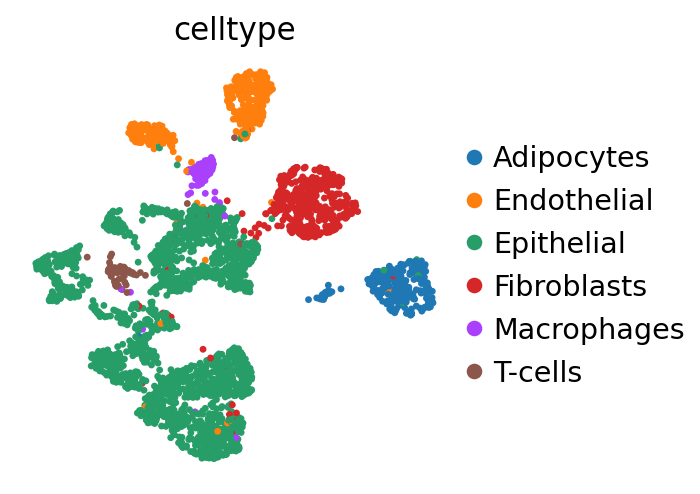

In [5]:
sc.pl.embedding(breast, basis='X_umap', color='celltype')

## GRN inference

In this section we showcase how to perform GRN inference from a multiome dataset.
We will run some of the baselines shown in the GRETA manuscript:

1) Literature derived networks: collectri and dorothea
2) Correlation based networks: pearson and spearman
3) A random network


<div class="alert alert-info">
    
**Note**

`gretapy` works with multimodal GRNs, meaning they should contain cis regulatory element (CRE) information in each edge.
If your method is based on just transcriptomics data, you can transform it to multimodal by filtering interactions based
on promoter accessibility, as it was done with all baselines in the GRETA manuscript.

You can easily achieve this by running: 

```
# grn = pd.DataFrame with source and target columns, with optional weight column
mgrn = gt.mt.lit_grn(organism='hg38', grn=grn)
```

</div>

In [6]:
grn_dict = {}

# CollecTRI
grn_dict['CollecTRI'] = gt.mt.lit_grn(mdata=breast, organism='hg38', grn='CollecTRI')
grn_dict['CollecTRI'].head()

,source,cre,target,score
0,AHR,chr7-87600646-87601146,ABCB1,1.0
1,AHR,chr4-88230899-88231399,ABCG2,1.0
2,AHR,chr17-78186409-78186909,AFMID,1.0
3,AHR,chr7-16804717-16805217,AGR2,1.0
4,AHR,chr5-320864-321364,AHRR,1.0


In [7]:
# DoRothEA
grn_dict['DoRothEA'] = gt.mt.lit_grn(mdata=breast, organism='hg38', grn='DoRothEA')
grn_dict['DoRothEA'].head()

,source,cre,target,score
0,AHR,chr7-28298823-28299323,CREB5,1
1,AHR,chr5-138610325-138610825,CTNNA1,1
2,AHR,chr14-75278576-75279076,FOS,1
3,AHR,chr10-14329796-14330296,FRMD4A,1
4,AHR,chr5-66596058-66596558,MAST4,1


In [8]:
# Pearson
grn_dict['Pearson'] = gt.mt.correlation(mdata=breast, organism='hg38', method='pearson')
grn_dict['Pearson'].head()

,source,cre,target,score
0,PROX1,chr8-109362206-109362706,PKHD1L1,0.660204
1,MECOM,chr2-56183529-56184029,CCDC85A,0.648627
2,MECOM,chr13-28493920-28494420,FLT1,0.620280
3,MLXIPL,chr11-14642937-14643437,PDE3B,0.614183
4,MECOM,chr5-149141226-149141726,ABLIM3,0.611630


In [9]:
# Spearman
grn_dict['Spearman'] = gt.mt.correlation(mdata=breast, organism='hg38', method='pearson')
grn_dict['Spearman'].head()

,source,cre,target,score
0,PROX1,chr8-109362206-109362706,PKHD1L1,0.660204
1,MECOM,chr2-56183529-56184029,CCDC85A,0.648627
2,MECOM,chr13-28493920-28494420,FLT1,0.620280
3,MLXIPL,chr11-14642937-14643437,PDE3B,0.614183
4,MECOM,chr5-149141226-149141726,ABLIM3,0.611630


In [10]:
# Random
grn_dict['Random'] = gt.mt.random(mdata=breast, organism='hg38')
grn_dict['Random'].head()

,source,cre,target,score
0,AEBP1,chr15-69462602-69463102,RPLP1,1.0
1,AEBP1,chr15-89367677-89368177,FANCI,1.0
2,AEBP1,chr17-59707337-59707837,DHX40,1.0
3,AEBP1,chr19-17841978-17842478,JAK3,1.0
4,AEBP1,chr19-33054541-33055041,GPATCH1,1.0


## GRN statistics

Then we can compute different statistics across a collection of GRNs. For example we can compute their similarity at the source, cre, target and edge levels:

In [11]:
oc_df = gt.tl.ocoeff(grn_dict)
oc_df

,grn_a,grn_b,source,cre,target,edge
0,CollecTRI,DoRothEA,0.790960,0.585267,0.578685,0.333719
1,CollecTRI,Pearson,0.706271,0.699338,0.667391,0.047101
2,CollecTRI,Spearman,0.706271,0.699338,0.667391,0.047101
3,CollecTRI,Random,0.287129,0.069757,0.149415,0.000308
4,DoRothEA,Pearson,0.672316,0.716953,0.691235,0.071561
5,DoRothEA,Spearman,0.672316,0.716953,0.691235,0.071561
6,DoRothEA,Random,0.265537,0.070636,0.143426,0.000308
7,Pearson,Spearman,1.000000,1.000000,1.000000,1.000000
8,Pearson,Random,0.415929,0.109708,0.290279,0.002157
9,Spearman,Random,0.415929,0.109708,0.290279,0.002157


We can visualize this as a matrix. Here we can see that methods tend to produce very different networks at the edge level, as measured by the overlap coefficient.

<div class="alert alert-info">
    
**Note**

We use the overlap coefficient instead of the Jaccard index because GRN methods produce networks of vastly different sizes. The overlap coefficient normalizes to the smaller network:

$$\text{Overlap}(A, B) = \frac{|A \cap B|}{\min(|A|, |B|)}$$

For example, if method A infers 1,000 edges, method B infers 10,000, and they share 900 edges:
- Jaccard = 900 / 10,100 ≈ 0.09 (suggests almost no agreement, but this is driven by the size difference)
- Overlap = 900 / 1,000 = 0.90 (90% of the smaller network's edges are recovered)

The overlap coefficient asks the more meaningful question: to what extent is the smaller network's regulatory logic recovered in the larger network?

</div>

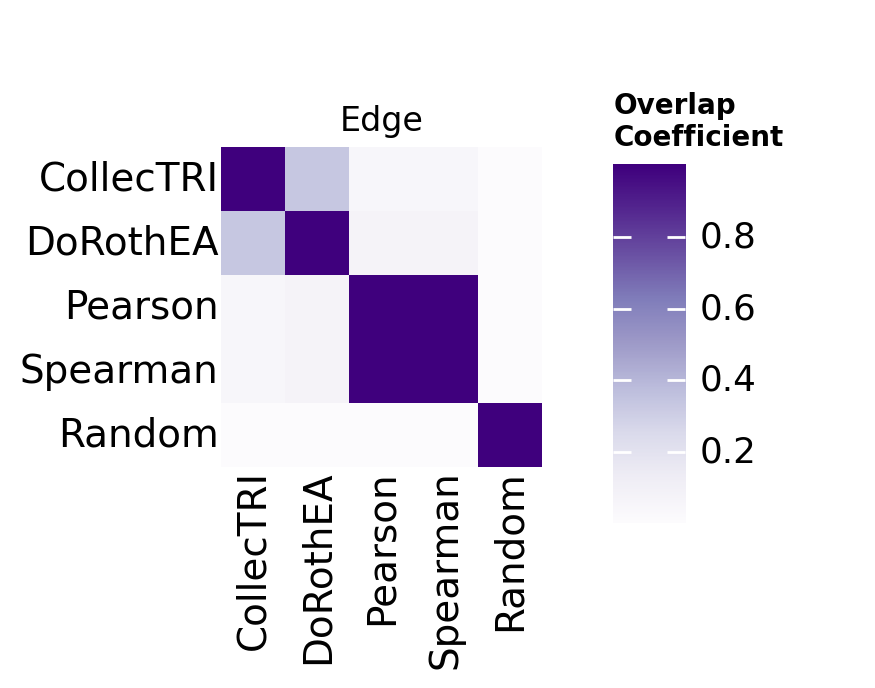

In [12]:
gt.pl.heatmap(oc_df, level='edge', order=grn_dict.keys())

We can also compute network size statistics like:
- Number of unique sources (TFs)
- Number of unique CREs
- Number of unique target genes
- Number of edges
- Mean regulon size (how many targets does a TF have)

In [13]:
st_df = gt.tl.stats(grn_dict)
st_df

,name,n_sources,n_cres,n_targets,n_edges,mean_regulon_size
0,CollecTRI,303,2265,2300,10658,35.174917
1,DoRothEA,177,1982,2008,4318,24.395480
2,Pearson,558,4561,4793,68940,123.548387
3,Spearman,558,4561,4793,68940,123.548387
4,Random,339,2534,2222,3246,9.575221


Which we can also visualize. Here we see that, for example, correlation-based methods Pearson and Spearman produce GRNs that are bigger than literature-derived networks (CollecTRI and DoRothEA) or the random network.

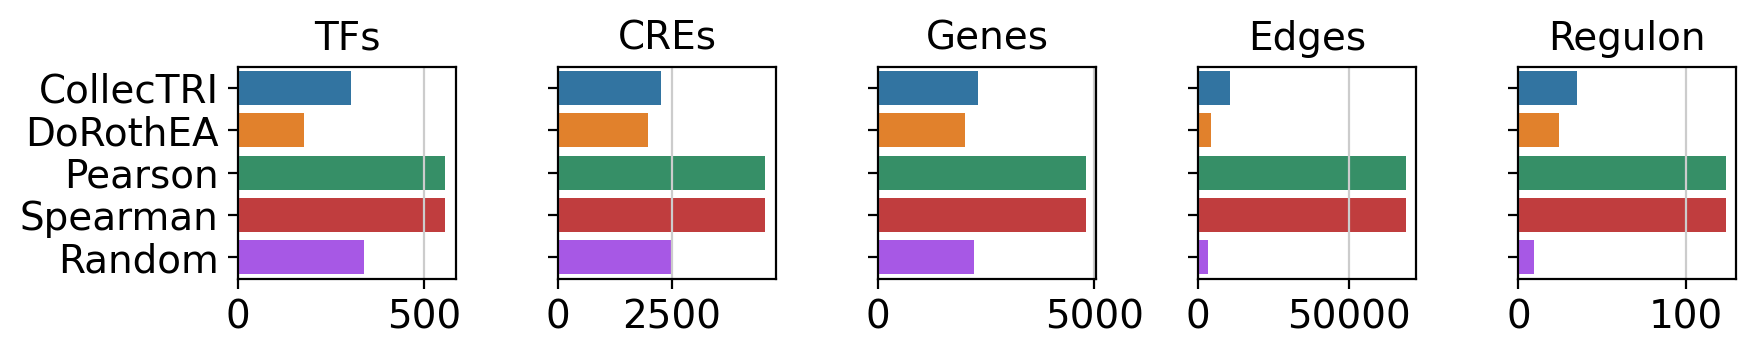

In [14]:
gt.pl.stats(st_df)

Another useful statistic to compute is the distance of CREs to the TSS of their target genes.

In [15]:
dt_df = gt.tl.cre_to_tss_distance(grns=grn_dict, organism='hg38')
dt_df

,grn,cre,target,distance
0,CollecTRI,chr7-87600646-87601146,ABCB1,0
1,CollecTRI,chr4-88230899-88231399,ABCG2,0
2,CollecTRI,chr17-78186409-78186909,AFMID,0
3,CollecTRI,chr7-16804717-16805217,AGR2,0
4,CollecTRI,chr5-320864-321364,AHRR,0
...,...,...,...,...
16648,Random,chr3-114291520-114292020,ZBTB20-AS5,152500
16649,Random,chr4-70688045-70688545,MOB1B,212780
16650,Random,chr6-26045025-26045525,H2BC3,313
16651,Random,chrX-112642263-112642763,AMOT,197051


Which we can visualize using the plot below. Here we see that only the Random network uses distal CREs; the other methods rely on proximal CREs when defining TF-CRE-Gene interactions.

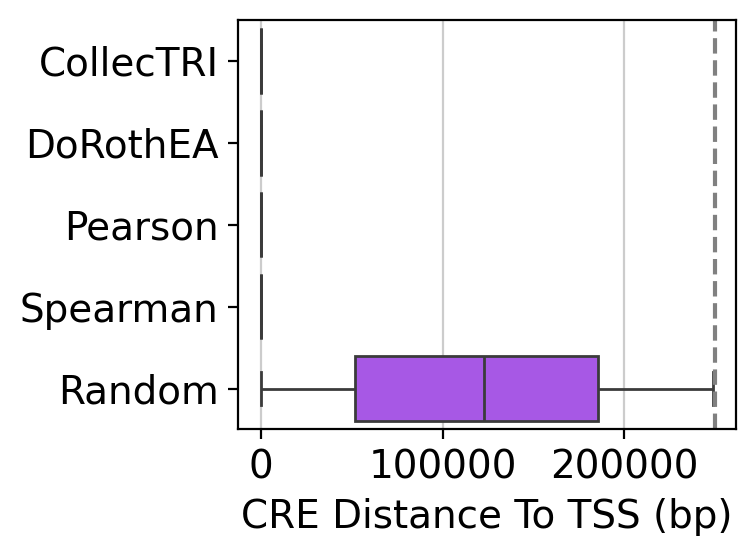

In [16]:
gt.pl.cre_to_tss_distance(dt_df, thr_distance=250_000)

We can also plot specific TF-CRE-Gene interactions on the genome. In the below plot we see at the top the TF-CRE-Gene interaction, the height means that it has more score than other interactions in that network. In the middle we see the expression of the target gene and its neighbours (Purple), and in yellow we see the accessibility of chromatin peaks (height means more accesibility). On the bottom there is the genome annotation, where genes are.

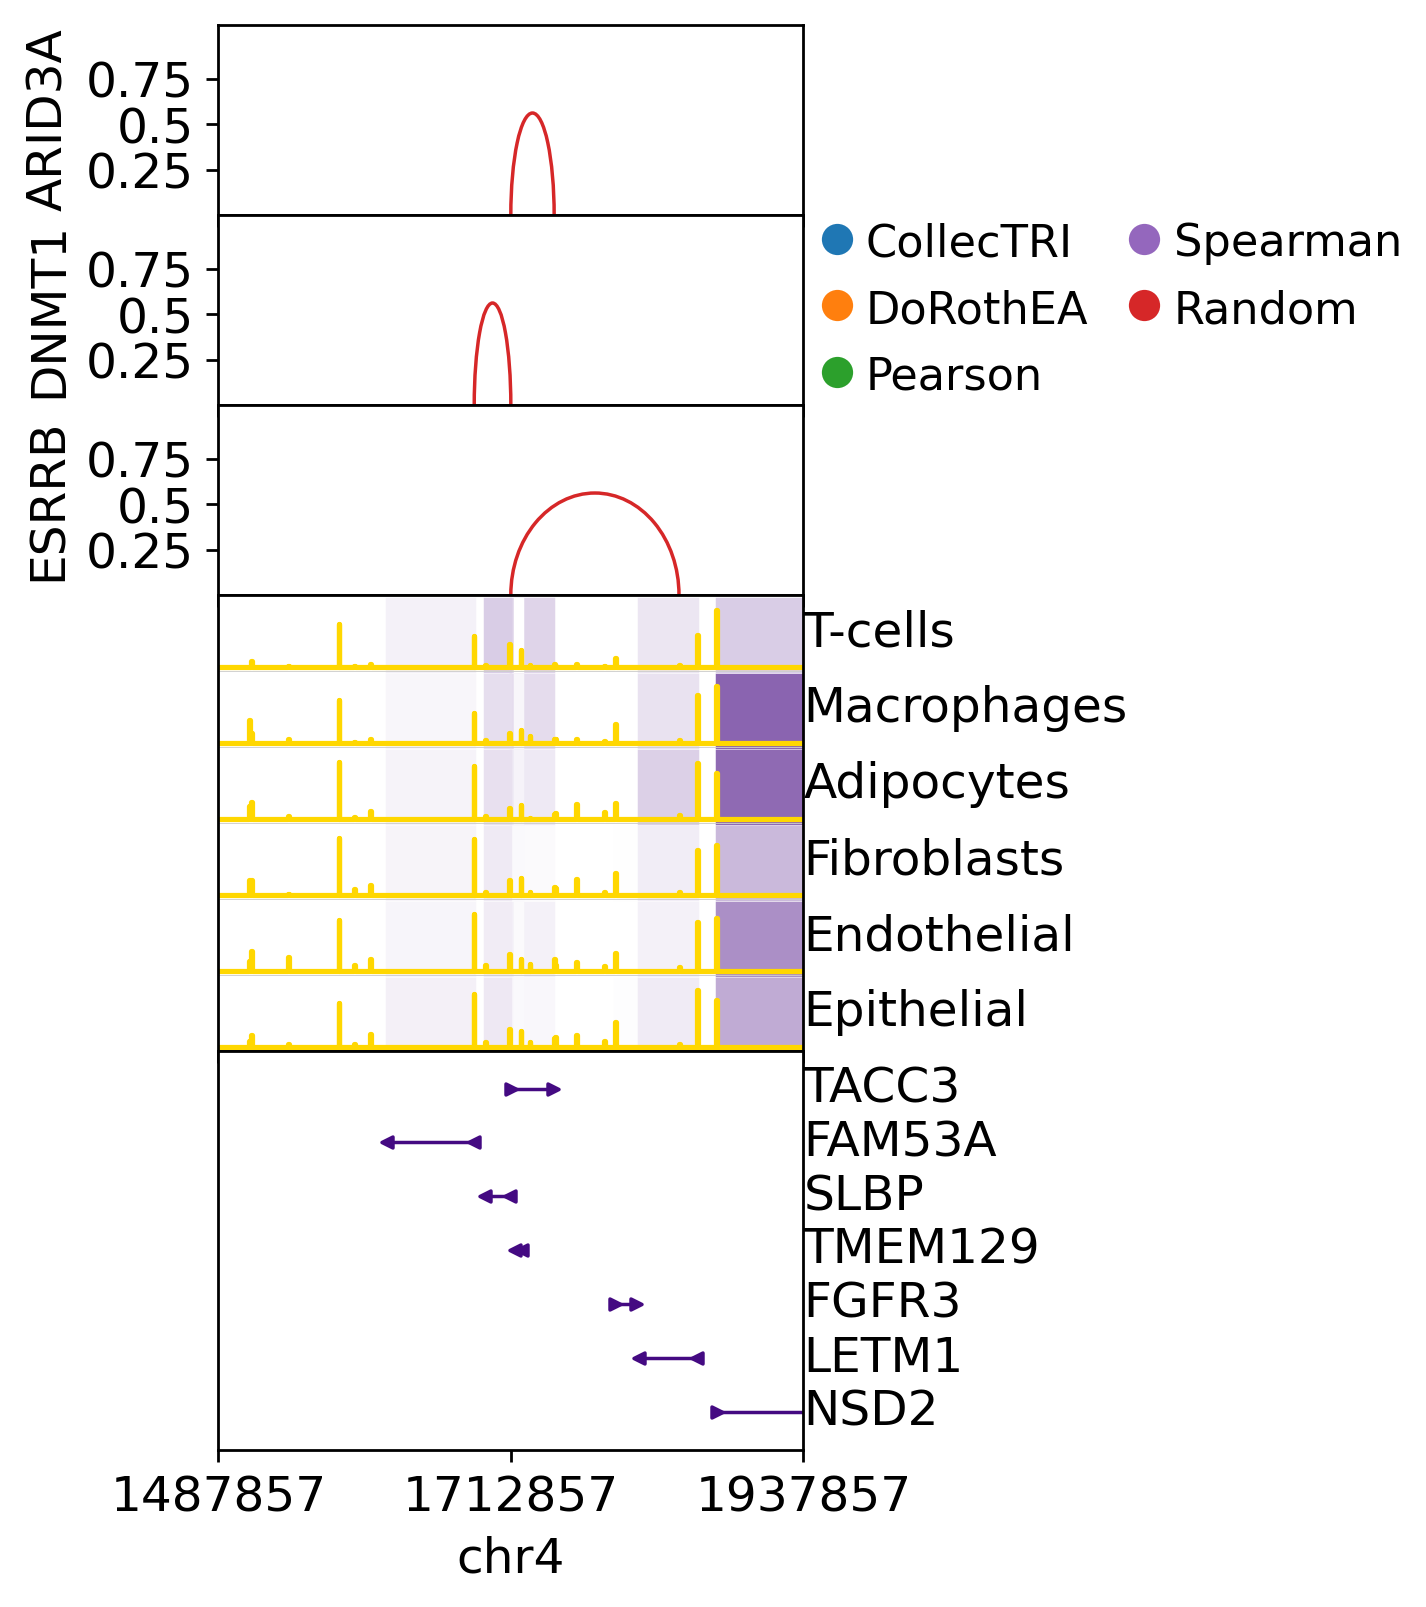

In [17]:
gt.pl.links(mdata=breast, grn=grn_dict, target='TACC3', tfs=['ARID3A', 'DNMT1', 'ESRRB'], w_size=225_000)

We can visualize the network also as a graph.

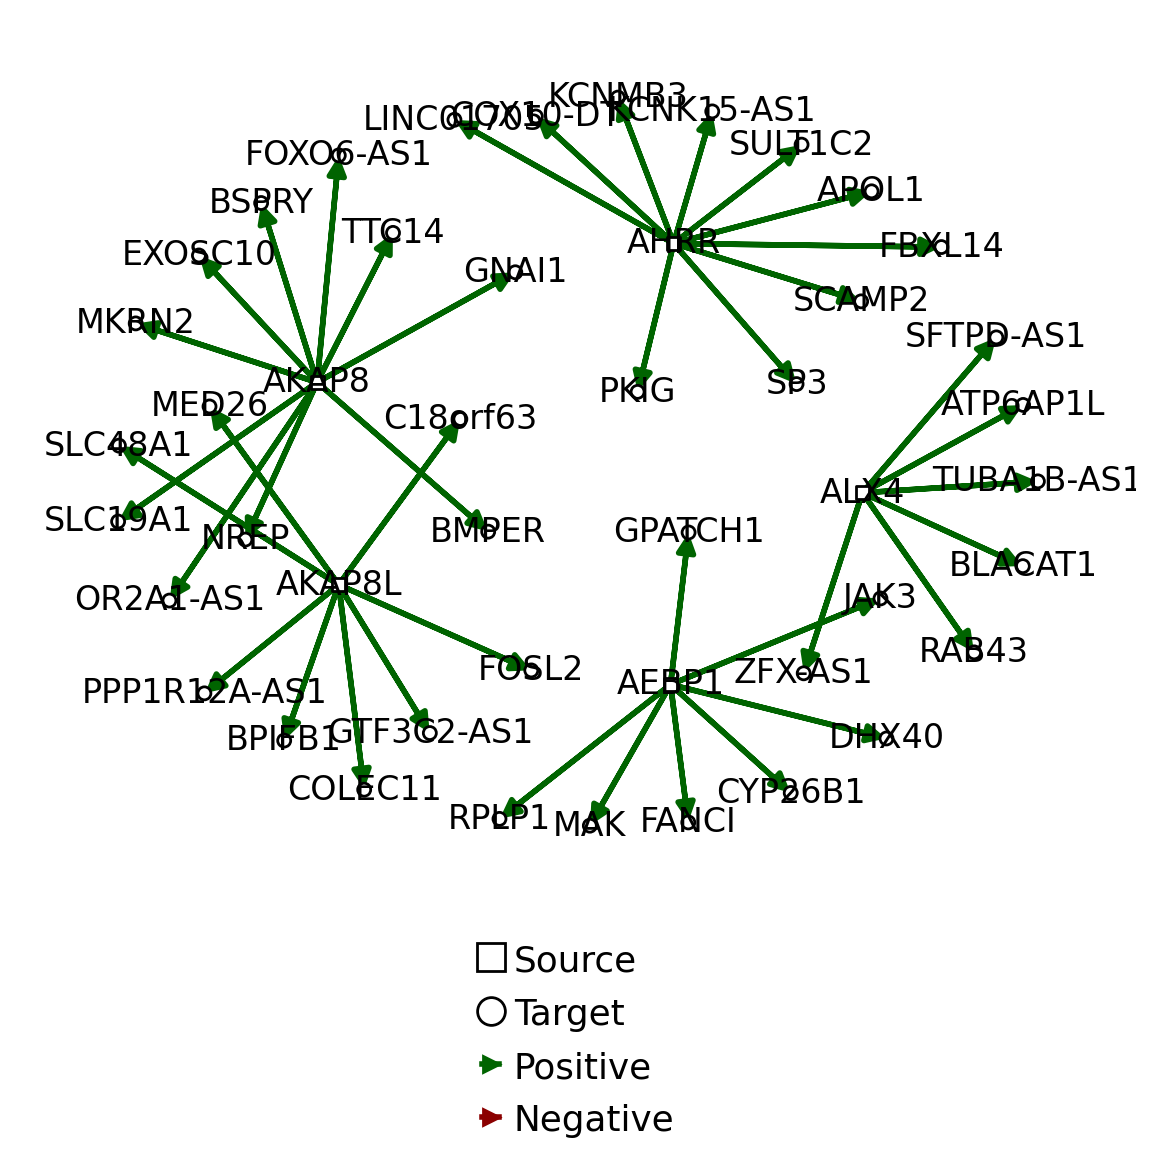

In [18]:
dc.pl.network(net=grn_dict['Random'], figsize=(6, 6))